# Reconstruction on the shared m/z windows: both axes, every stage

Is reconstruction inside 200-900 m/z better on the narrow or on the wide axis for the baseline and for every pretraining variant and stage, and does the wide axis profit more from pretraining?

## Introduction

The thesis tested in parts 2-6 is that synthetic pretraining improves on the model trained on real data only.
Every table therefore contains the **real-only baseline** of the same axis (10 real epochs from the same
initialization) and every comparison is a **paired difference to that baseline**.

The ten pretraining variants differ only in the synthetic data seen before real data (campaign methodology,
`pretraining_campaign_methodology.md`):

| Variant | Synthetic phases | Construction |
| --- | --- | --- |
| P0 single bins | 1 x 10 epochs | ten spectra per axis bin; annotated bins carry their labels, blank bins are known negatives |
| P1 permutations | 1 x 10 epochs | component-token bag (30 per class and per blank bin) packed into mixed spectra |
| P2 joint / staged | 1 x 10 / 2 x 10 epochs | P0 and P1 rows shuffled together / P0 first, then P1 |
| P3 joint / staged | as P2 | P2 + overlap quota (30 extra tokens per class that shares a bin with another class in a training pixel) |
| P4 joint / staged | as P2 | P2 + rare quota (30 extra tokens per class of the least-annotated quarter) |
| P5 joint / staged | as P2 | P2 + both quotas |

Every variant yields three models along one lineage (stages): `pretrained`, `frozen_head` and `unfrozen_head`.
The staged schedules train twice as many synthetic epochs as the joint ones, so schedule and budget are
confounded (methodology, "Pretraining ablation").

### Assumptions

* **Pairing.** Repetition $r$ uses one initialization seed for the baseline and for every variant and stage
  (verified for all 310 models in the campaign-plan verification). The difference between a variant and the
  baseline of the same repetition removes the initialization effect; the five repetitions are the independent
  units. Pixels are not independent units and never enter a test as such.
* **Data.** Every model is evaluated on identical pixels: the same `train`, `test`, `test_extended` and
  `heldout_image` populations as in part 1, decoded once in the shared cache.
* **Objectives.** Synthetic phases: Masserstein (1.0) + BCE (0.2) on complete synthetic targets. Real phases
  (baseline and both fine-tuning stages): Masserstein (1.0) + VPU (0.2) + contractive (2e-3) + InfoNCE (1e-3,
  multilabel-Jaccard negatives, added by mistake and kept because every model used it).
* **Threshold metrics.** Precision, recall and F1 use $\hat Y \ge 0.5$, as in part 1. A head whose
  probabilities never reach 0.5 on real data has F1 = 0 although its ranking may still carry information;
  average precision is threshold free and is the primary head metric.
* **Uncertainty.** With five repetitions the Student-t interval has 4 degrees of freedom
  ($t_{0.975,4} = 2.78$); an interval that excludes zero is a strong statement, one that includes zero is not
  evidence of no effect.

* **Comparable quantities only.** Global $W_1$ is not comparable across axes (different m/z ranges and bins).
  Reconstruction is compared on the 100 Da windows inside 200-900 m/z shared by both axes, the head on the classes
  that are head columns on both axes (`common`), the latent capacity by dimension-free quantities.
* **Axis difference** $s_m(v^{\mathrm{wide}}_r - v^{\mathrm{narrow}}_r)$, paired by variant, stage and repetition
  (identical pixels and initialization seed across axes): positive = the 100-3000 axis is better.
* **Benefit interaction** $\Delta^{\mathrm{wide}}_r - \Delta^{\mathrm{narrow}}_r$: positive = the wide axis gains
  more from pretraining (relative to its own baseline) than the narrow axis.

### Notation

* $b_r$, $v_r$: value of a metric for the baseline and for a variant (at one stage) in repetition $r$.
* $s_m \in \{-1, +1\}$: direction of metric $m$; $-1$ for lower-is-better metrics (Masserstein $W_1$,
  spectral angle, MSE, Hamming loss, window contribution and within-window $W_1$, absolute mass imbalance, ECE,
  Brier score, true-label rank, false-positive rate and lift, losses), $+1$ otherwise.
* **Improvement** $\Delta_r = s_m (v_r - b_r)$: positive is always better than the baseline.
  **Relative improvement** $\Delta_r / |b_r|$.
* Summary over repetitions: mean $\bar\Delta$, SD $s$, interval $\bar\Delta \pm t_{0.975, n-1}\, s / \sqrt{n}$,
  and the numbers of repetitions with $\Delta_r > 0$ (`+k`) and $\Delta_r < 0$ (`-m`).
* Evaluations: `test` (withheld pixels of training images), `test_combined` (test + rare-class extension, the
  main per-class estimate), `heldout_image` (three images never seen; pooled), `heldout_image_per_image` (mean of
  the per-image values; pooled held-out values understate the ranking because annotations are incomplete across
  images, part 1_08).
* $W_1$: exact one-dimensional Wasserstein-1 distance between TIC-normalized input and reconstruction (m/z
  units); $u$: canonical latent code (LayerNorm affine removed).

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "axis_reconstruction_common"
AXIS = None
STAGE = None

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS, STAGE)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS, STAGE)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| stage:", STAGE, "| models:", metadata["models"] if isinstance(metadata["models"], int) else len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

BASELINE = "baseline"
VARIANTS = list(settings["variants"])
VARIANT_LABELS = {BASELINE: "real-only baseline", **{name: value["label"] for name, value in settings["variants"].items()}}
## The baseline keeps its catalog colour (the dark theme baseline colour is reserved for reference lines)
BASELINE_COLOR = next(value["visualization"]["color"] for value in settings["models"].values()
                      if value.get("select", {}).get("role") == settings["baseline_role"])
VARIANT_COLORS = {BASELINE: BASELINE_COLOR, **{name: value["color"] for name, value in settings["variants"].items()}}
STAGES = list(settings["stages"])
STAGE_LABELS = {"real_only": "real-only baseline", **{name: value["label"] for name, value in settings["stages"].items()}}
KEY_METRICS = settings["comparison"]["key_metrics"]
AXES = list(settings["axes"])
AXIS_LABELS = {name: value["label"] for name, value in settings["axes"].items()}
SHORT = {"masserstein": "W1", "spectral_angle": "spectral angle", "average_precision": "macro AP",
         "micro_average_precision": "micro AP", "f1": "macro F1 at 0.5"}
EVALUATION_NAMES = {**figures.DISPLAY_NAMES, "heldout_image_per_image": "held-out, per image"}


def key_panels(reconstruction=("test", "heldout_image"), prediction=("test_combined", "heldout_image_per_image")):
    """Forest-plot panels of the key metrics: (title, row selector)."""
    panels = []
    for spec in KEY_METRICS:
        for evaluation in (reconstruction if spec["family"] == "reconstruction" else prediction):
            selector = {"family": spec["family"], "metric": spec["metric"], "evaluation": evaluation,
                        "ranking": spec.get("ranking", "none")}
            panels.append((f"{SHORT.get(spec['metric'], spec['metric'])}, {EVALUATION_NAMES.get(evaluation, evaluation)}", selector))
    return panels


def interval(frame, digits=3):
    """'mean [ci_low, ci_high] (+k/-m)' strings of a summary table."""
    form = "{:." + str(digits) + "g}"
    return (frame["mean"].map(form.format) + " [" + frame.ci_low.map(form.format) + ", "
            + frame.ci_high.map(form.format) + "] (+" + frame.positive.astype(int).astype(str) + "/-"
            + frame.negative.astype(int).astype(str) + ")")

from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_comparison import summarize

ORDER = [BASELINE, *VARIANTS]

PANELS = [('contribution, test', {'metric': 'contribution', 'evaluation': 'test'}), ('contribution, held-out', {'metric': 'contribution', 'evaluation': 'heldout_image'}), ('within-window W1, held-out', {'metric': 'within', 'evaluation': 'heldout_image'})]

Analysis: axis_reconstruction_common | axis: None | stage: None | models: 310
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'synthetic_reference': '6ba5bc1e0839ba0e', 'inference': '0243c1efb93b9c4c'}


## Producing the tables this notebook reads

### Methodology

#### Implementation

`axis_reconstruction_common` sums the window contributions to $W_1$ over the shared windows (the part of
the transport cost paid inside 200-900 m/z) and averages the within-window $W_1$ over them, per model and
population.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis axis_reconstruction_common > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Absolute values of both axes against their real-only baselines

### Methodology

#### Theoretical

The axis-comparison statistics as levels: for every axis, the value of each model (baseline and every stage),
so that a difference between axes can be read against what each axis reaches.

#### Implementation

`metrics` holds one value per model, metric and evaluation population on both axes.

#### Figure descriptions

        Figure: one panel per axis, metric and evaluation; x = real-only baseline and stages (variants pooled: 50 models
        per stage against 5 baseline models). Tables: rows = baseline and variants, columns = axis | stage; the
        baseline row repeats each axis's baseline value.
        Last figure: the unfrozen-head stage only, split by variant (x = real-only baseline and every variant, five
        repetitions each), because pooling the variants of a stage mixes variants with very different effects.

Colours: in the figures the baseline is grey (its mean is the dashed line) and every other group is green when its
mean is better than the baseline mean and red when it is worse. In the tables every cell is mean +/- SD over the
repetitions; green / red cells are better / worse than the baseline cell of the same column (stronger colour = larger
difference within the column), the black frame marks the three best rows of the column and the grey bold row is the
real-only baseline.

In [3]:
LOWER_IS_BETTER = {'masserstein', 'spectral_angle', 'mse', 'hamming_loss', 'expected_calibration_error', 'brier_score',
                   'within', 'contribution', 'absolute_mass_imbalance', 'bic'}
METRIC_ORDER = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_roc_auc', 'ap_above_prevalence',
                'precision', 'recall', 'f1', 'micro_precision', 'micro_recall', 'micro_f1', 'micro_prevalence',
                'hamming_loss']
ABS_ORDER = [BASELINE, *VARIANTS]
LABELS_ABS = {**VARIANT_LABELS, **{name: VARIANT_LABELS.get(name, name) for name in ABS_ORDER}}


def better(metric):
    """Direction of a metric: 'lower' or 'higher' is better."""
    return 'lower' if metric in LOWER_IS_BETTER else 'higher'

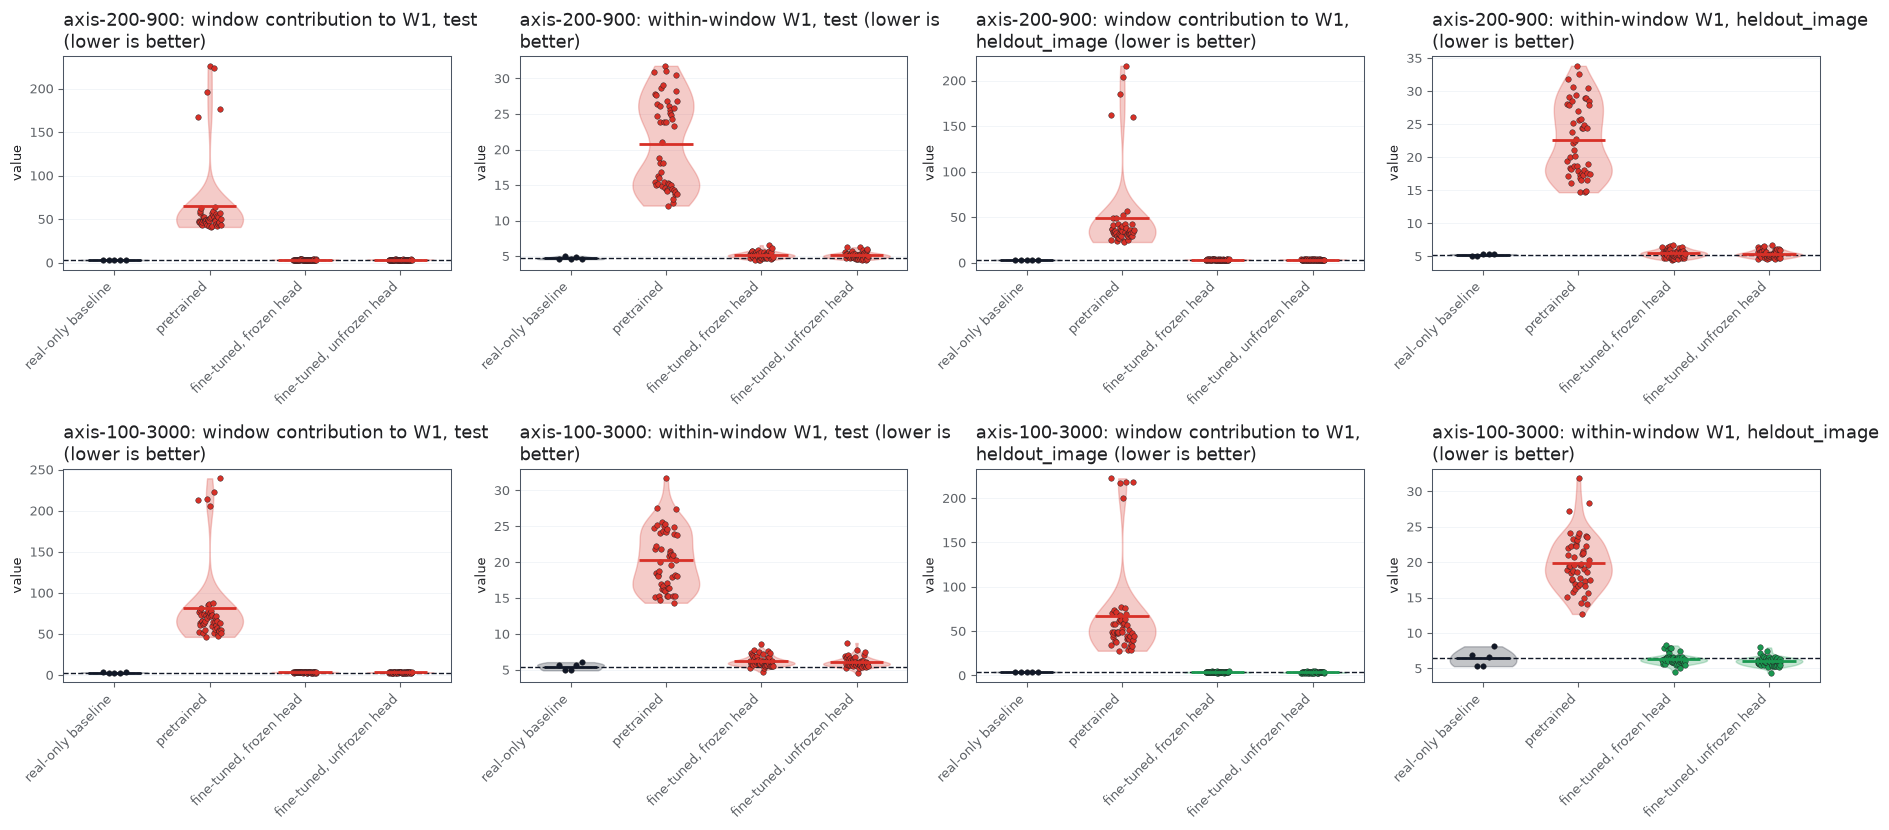

contribution | heldout_image


column,axis-200-900 | pretrained,axis-200-900 | frozen_head,axis-200-900 | unfrozen_head,axis-100-3000 | pretrained,axis-100-3000 | frozen_head,axis-100-3000 | unfrozen_head
variant,,,,,,
baseline,3.076 +/- 0.143,3.076 +/- 0.143,3.076 +/- 0.143,3.885 +/- 0.263,3.885 +/- 0.263,3.885 +/- 0.263
P0_single,185.632 +/- 24.787,3.715 +/- 0.525,3.678 +/- 0.191,215.306 +/- 8.557,4.053 +/- 0.156,3.476 +/- 0.280
P1_permutation,25.799 +/- 2.581,2.966 +/- 0.114,3.123 +/- 0.337,31.710 +/- 3.011,3.548 +/- 0.122,3.313 +/- 0.312
P2_joint_base,34.328 +/- 5.988,3.475 +/- 0.353,3.320 +/- 0.277,47.952 +/- 3.841,3.472 +/- 0.240,3.407 +/- 0.347
P2_staged_base,34.137 +/- 6.829,3.297 +/- 0.289,3.213 +/- 0.245,52.992 +/- 12.992,4.052 +/- 0.397,3.634 +/- 0.145
P3_joint_overlap,34.893 +/- 3.518,3.435 +/- 0.502,3.494 +/- 0.379,40.964 +/- 6.229,3.489 +/- 0.376,3.494 +/- 0.406
P3_staged_overlap,33.563 +/- 5.702,3.206 +/- 0.349,3.426 +/- 0.280,55.399 +/- 17.949,4.016 +/- 0.395,3.770 +/- 0.447
P4_joint_rare,33.484 +/- 6.357,3.482 +/- 0.332,3.382 +/- 0.086,58.072 +/- 12.220,3.749 +/- 0.357,3.602 +/- 0.400
P4_staged_rare,38.207 +/- 6.986,3.399 +/- 0.403,3.597 +/- 0.173,64.861 +/- 13.620,3.805 +/- 0.343,3.885 +/- 0.647


contribution | test


column,axis-200-900 | pretrained,axis-200-900 | frozen_head,axis-200-900 | unfrozen_head,axis-100-3000 | pretrained,axis-100-3000 | frozen_head,axis-100-3000 | unfrozen_head
variant,,,,,,
baseline,3.117 +/- 0.109,3.117 +/- 0.109,3.117 +/- 0.109,3.087 +/- 0.120,3.087 +/- 0.120,3.087 +/- 0.120
P0_single,197.775 +/- 26.938,3.479 +/- 0.409,3.486 +/- 0.119,218.981 +/- 12.989,3.843 +/- 0.265,3.323 +/- 0.301
P1_permutation,46.056 +/- 2.657,2.938 +/- 0.062,3.025 +/- 0.142,53.388 +/- 4.786,3.004 +/- 0.080,2.940 +/- 0.125
P2_joint_base,50.160 +/- 6.343,3.493 +/- 0.256,3.427 +/- 0.086,71.499 +/- 5.118,3.252 +/- 0.311,3.097 +/- 0.207
P2_staged_base,45.214 +/- 2.680,3.318 +/- 0.220,3.175 +/- 0.186,64.284 +/- 11.166,3.480 +/- 0.280,3.470 +/- 0.284
P3_joint_overlap,52.983 +/- 2.360,3.540 +/- 0.352,3.468 +/- 0.181,57.845 +/- 11.050,3.398 +/- 0.315,3.245 +/- 0.392
P3_staged_overlap,48.194 +/- 5.284,3.220 +/- 0.242,3.249 +/- 0.157,66.983 +/- 14.003,3.483 +/- 0.206,3.228 +/- 0.201
P4_joint_rare,53.377 +/- 4.432,3.424 +/- 0.221,3.490 +/- 0.224,72.986 +/- 12.109,3.451 +/- 0.329,3.188 +/- 0.257
P4_staged_rare,48.983 +/- 6.597,3.291 +/- 0.312,3.436 +/- 0.222,70.808 +/- 9.965,3.493 +/- 0.264,3.517 +/- 0.216


within | heldout_image


column,axis-200-900 | pretrained,axis-200-900 | frozen_head,axis-200-900 | unfrozen_head,axis-100-3000 | pretrained,axis-100-3000 | frozen_head,axis-100-3000 | unfrozen_head
variant,,,,,,
baseline,5.222 +/- 0.130,5.222 +/- 0.130,5.222 +/- 0.130,6.468 +/- 1.180,6.468 +/- 1.180,6.468 +/- 1.180
P0_single,27.245 +/- 2.094,5.852 +/- 0.597,5.791 +/- 0.429,23.030 +/- 3.553,6.783 +/- 0.840,6.167 +/- 0.450
P1_permutation,18.280 +/- 2.112,5.344 +/- 0.261,5.330 +/- 0.411,16.866 +/- 1.597,5.681 +/- 0.774,5.651 +/- 0.849
P2_joint_base,27.399 +/- 5.167,5.051 +/- 0.488,5.206 +/- 0.738,20.294 +/- 2.342,6.608 +/- 1.267,5.801 +/- 0.462
P2_staged_base,17.270 +/- 2.341,5.285 +/- 0.738,5.011 +/- 0.320,19.531 +/- 2.010,6.392 +/- 0.784,6.113 +/- 0.575
P3_joint_overlap,27.789 +/- 3.479,5.826 +/- 0.706,5.667 +/- 0.551,22.810 +/- 5.518,6.266 +/- 0.331,5.741 +/- 0.349
P3_staged_overlap,18.417 +/- 3.138,5.361 +/- 0.600,5.479 +/- 0.664,16.205 +/- 1.946,6.174 +/- 0.249,6.078 +/- 0.428
P4_joint_rare,29.413 +/- 3.039,5.253 +/- 0.482,5.452 +/- 0.721,22.516 +/- 3.375,6.077 +/- 0.495,6.276 +/- 0.634
P4_staged_rare,18.333 +/- 2.610,5.584 +/- 0.634,5.577 +/- 0.491,17.743 +/- 3.667,6.734 +/- 0.984,6.564 +/- 1.199


within | test


column,axis-200-900 | pretrained,axis-200-900 | frozen_head,axis-200-900 | unfrozen_head,axis-100-3000 | pretrained,axis-100-3000 | frozen_head,axis-100-3000 | unfrozen_head
variant,,,,,,
baseline,4.747 +/- 0.186,4.747 +/- 0.186,4.747 +/- 0.186,5.460 +/- 0.489,5.460 +/- 0.489,5.460 +/- 0.489
P0_single,28.541 +/- 2.346,5.117 +/- 0.254,5.188 +/- 0.325,24.501 +/- 2.080,6.842 +/- 0.597,6.416 +/- 0.587
P1_permutation,14.180 +/- 1.254,4.748 +/- 0.185,4.652 +/- 0.136,16.199 +/- 1.107,5.329 +/- 0.392,5.298 +/- 0.427
P2_joint_base,25.051 +/- 2.970,5.368 +/- 0.764,5.386 +/- 0.504,22.473 +/- 2.296,6.627 +/- 0.821,6.316 +/- 0.294
P2_staged_base,14.462 +/- 1.638,4.943 +/- 0.407,4.777 +/- 0.323,17.197 +/- 1.261,6.080 +/- 0.431,5.941 +/- 0.349
P3_joint_overlap,26.638 +/- 2.901,5.454 +/- 0.269,5.383 +/- 0.502,23.840 +/- 4.616,6.682 +/- 0.714,6.239 +/- 0.496
P3_staged_overlap,15.628 +/- 1.811,4.968 +/- 0.263,4.946 +/- 0.378,15.795 +/- 1.391,5.786 +/- 0.251,5.673 +/- 0.044
P4_joint_rare,27.766 +/- 2.499,5.363 +/- 0.316,5.584 +/- 0.407,24.092 +/- 2.699,6.207 +/- 0.690,6.840 +/- 1.278
P4_staged_rare,15.575 +/- 1.823,5.193 +/- 0.463,5.212 +/- 0.281,17.261 +/- 2.402,6.164 +/- 0.475,6.097 +/- 0.811


In [4]:
metrics_abs = table('metrics')
SELECTORS_ABS = [["axis-200-900: window contribution to W1, test", {"axis": "axis-200-900", "family": "common_windows", "metric": "contribution", "evaluation": "test", "ranking": "none"}, "lower"], ["axis-200-900: within-window W1, test", {"axis": "axis-200-900", "family": "common_windows", "metric": "within", "evaluation": "test", "ranking": "none"}, "lower"], ["axis-200-900: window contribution to W1, heldout_image", {"axis": "axis-200-900", "family": "common_windows", "metric": "contribution", "evaluation": "heldout_image", "ranking": "none"}, "lower"], ["axis-200-900: within-window W1, heldout_image", {"axis": "axis-200-900", "family": "common_windows", "metric": "within", "evaluation": "heldout_image", "ranking": "none"}, "lower"], ["axis-100-3000: window contribution to W1, test", {"axis": "axis-100-3000", "family": "common_windows", "metric": "contribution", "evaluation": "test", "ranking": "none"}, "lower"], ["axis-100-3000: within-window W1, test", {"axis": "axis-100-3000", "family": "common_windows", "metric": "within", "evaluation": "test", "ranking": "none"}, "lower"], ["axis-100-3000: window contribution to W1, heldout_image", {"axis": "axis-100-3000", "family": "common_windows", "metric": "contribution", "evaluation": "heldout_image", "ranking": "none"}, "lower"], ["axis-100-3000: within-window W1, heldout_image", {"axis": "axis-100-3000", "family": "common_windows", "metric": "within", "evaluation": "heldout_image", "ranking": "none"}, "lower"]]
STAGE_ORDER = ['real_only', *STAGES]
figures.metric_panels(metrics_abs, panels=[tuple(item) for item in SELECTORS_ABS], group='stage', order=STAGE_ORDER,
                      labels=STAGE_LABELS, baseline='real_only', columns=4, theme=theme);
plt.show()
for (family, metric, evaluation, ranking), rows in metrics_abs.groupby(['family', 'metric', 'evaluation', 'ranking']):
    base = rows[rows.stage == 'real_only']
    grid = pd.concat([rows[rows.stage != 'real_only'], *[base.assign(stage=stage) for stage in STAGES]])
    grid = grid.assign(column=grid.axis + ' | ' + grid.stage)
    columns = [f'{axis} | {stage}' for axis in AXES for stage in STAGES]
    print(metric, '|', evaluation)
    display(figures.comparison_table(grid, index='variant', columns='column', baseline=BASELINE, order=ABS_ORDER,
                                     column_order=columns, direction={column: better(metric) for column in columns}))

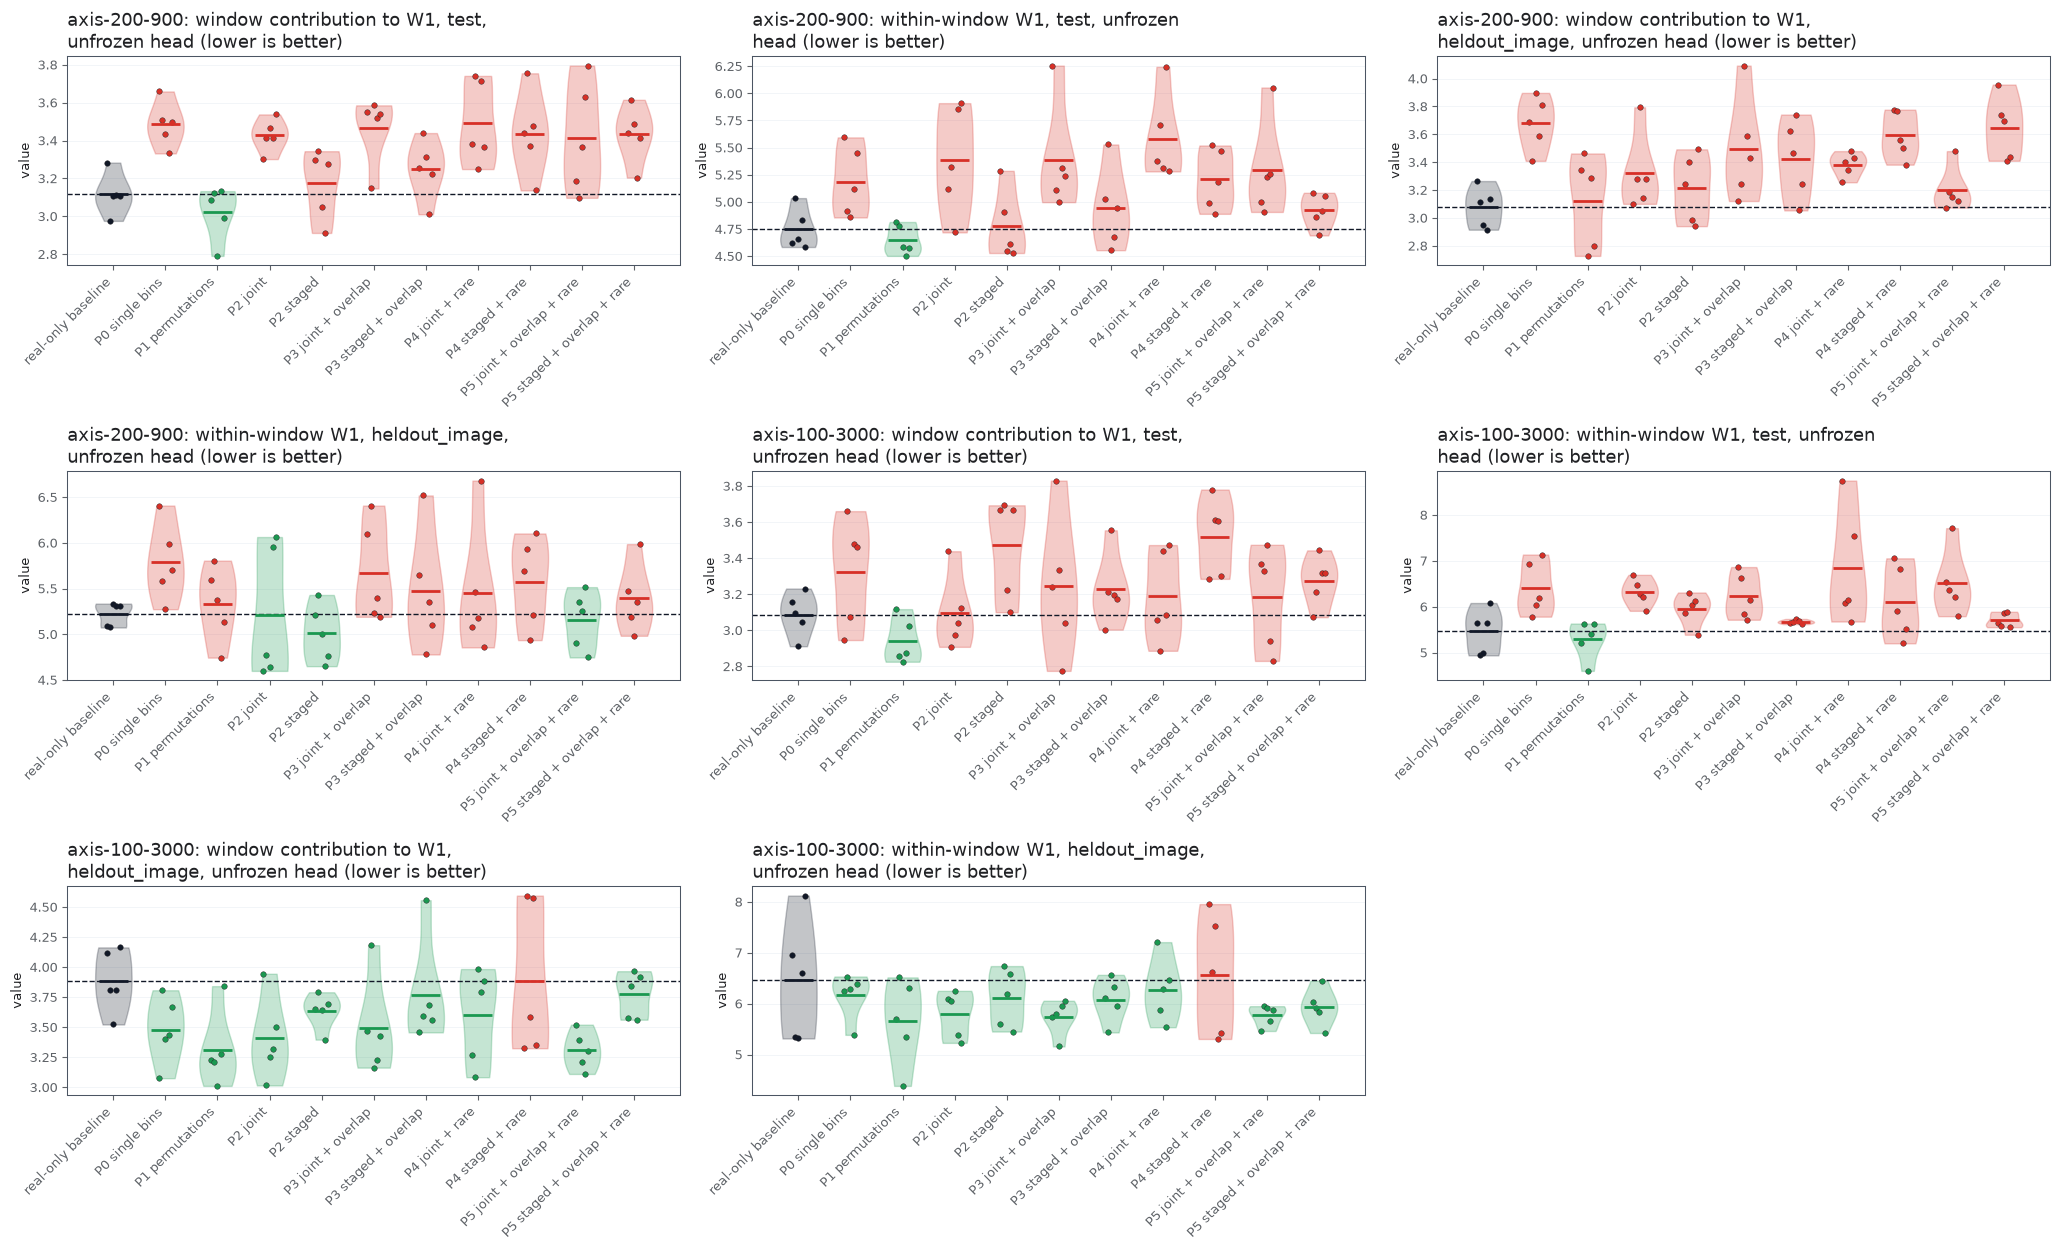

In [5]:
## Unfrozen-head stage per variant (the pooled figure above mixes variants with different effects)
unfrozen = frame_abs[frame_abs.stage.isin(['real_only', 'unfrozen_head'])] if 'frame_abs' in globals() else metrics_abs[metrics_abs.stage.isin(['real_only', 'unfrozen_head'])]
figures.metric_panels(unfrozen, panels=[(f'{label}, unfrozen head', selector, direction) for label, selector, direction in SELECTORS_ABS],
                      group='variant', order=ABS_ORDER, labels=LABELS_ABS, baseline=BASELINE, columns=3, theme=theme);

### Remarks

- axis-200-900: window contribution to W1, test (by stage): baseline 3.117; others 3.36-64.55; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (3.36), worst pretrained (64.55).
- axis-200-900: window contribution to W1, test (unfrozen head, per variant): baseline 3.117; others 3.025-3.49; 1 of 10 better than the baseline; best P1 permutations (3.025), worst P4 joint + rare (3.49).
- axis-200-900: within-window W1, test (by stage): baseline 4.747; others 5.134-20.81; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (5.134), worst pretrained (20.81).
- axis-200-900: within-window W1, test (unfrozen head, per variant): baseline 4.747; others 4.652-5.584; 1 of 10 better than the baseline; best P1 permutations (4.652), worst P4 joint + rare (5.584).
- axis-200-900: window contribution to W1, heldout_image (by stage): baseline 3.076; others 3.401-49.63; 0 of 3 better than the baseline; best fine-tuned, frozen head (3.401), worst pretrained (49.63).
- axis-200-900: window contribution to W1, heldout_image (unfrozen head, per variant): baseline 3.076; others 3.123-3.678; 0 of 10 better than the baseline; best P1 permutations (3.123), worst P0 single bins (3.678).
- axis-200-900: within-window W1, heldout_image (by stage): baseline 5.222; others 5.406-22.68; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (5.406), worst pretrained (22.68).
- axis-200-900: within-window W1, heldout_image (unfrozen head, per variant): baseline 5.222; others 5.011-5.791; 3 of 10 better than the baseline; best P2 staged (5.011), worst P0 single bins (5.791).
- axis-100-3000: window contribution to W1, test (by stage): baseline 3.087; others 3.247-81; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (3.247), worst pretrained (81).
- axis-100-3000: window contribution to W1, test (unfrozen head, per variant): baseline 3.087; others 2.94-3.517; 1 of 10 better than the baseline; best P1 permutations (2.94), worst P4 staged + rare (3.517).
- axis-100-3000: within-window W1, test (by stage): baseline 5.46; others 6.105-20.28; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (6.105), worst pretrained (20.28).
- axis-100-3000: within-window W1, test (unfrozen head, per variant): baseline 5.46; others 5.298-6.84; 1 of 10 better than the baseline; best P1 permutations (5.298), worst P4 joint + rare (6.84).
- axis-100-3000: window contribution to W1, heldout_image (by stage): baseline 3.885; others 3.566-66.8; 2 of 3 better than the baseline; best fine-tuned, unfrozen head (3.566), worst pretrained (66.8).
- axis-100-3000: window contribution to W1, heldout_image (unfrozen head, per variant): baseline 3.885; others 3.307-3.885; 9 of 10 better than the baseline; best P5 joint + overlap + rare (3.307), worst P4 staged + rare (3.885).
- axis-100-3000: within-window W1, heldout_image (by stage): baseline 6.468; others 6.009-19.88; 2 of 3 better than the baseline; best fine-tuned, unfrozen head (6.009), worst pretrained (19.88).
- axis-100-3000: within-window W1, heldout_image (unfrozen head, per variant): baseline 6.468; others 5.651-6.564; 9 of 10 better than the baseline; best P1 permutations (5.651), worst P4 staged + rare (6.564).

### Notes

## Wide minus narrow axis

### Methodology

#### Theoretical

The paired axis difference of every model cell (baseline and every variant and stage).

#### Implementation

`axis_differences` (per repetition) and `axis_difference_summary`.

#### Figure descriptions

Forest plot: rows = baseline and variants, panels = stage x quantity; the baseline row is repeated in
every stage panel as the reference.

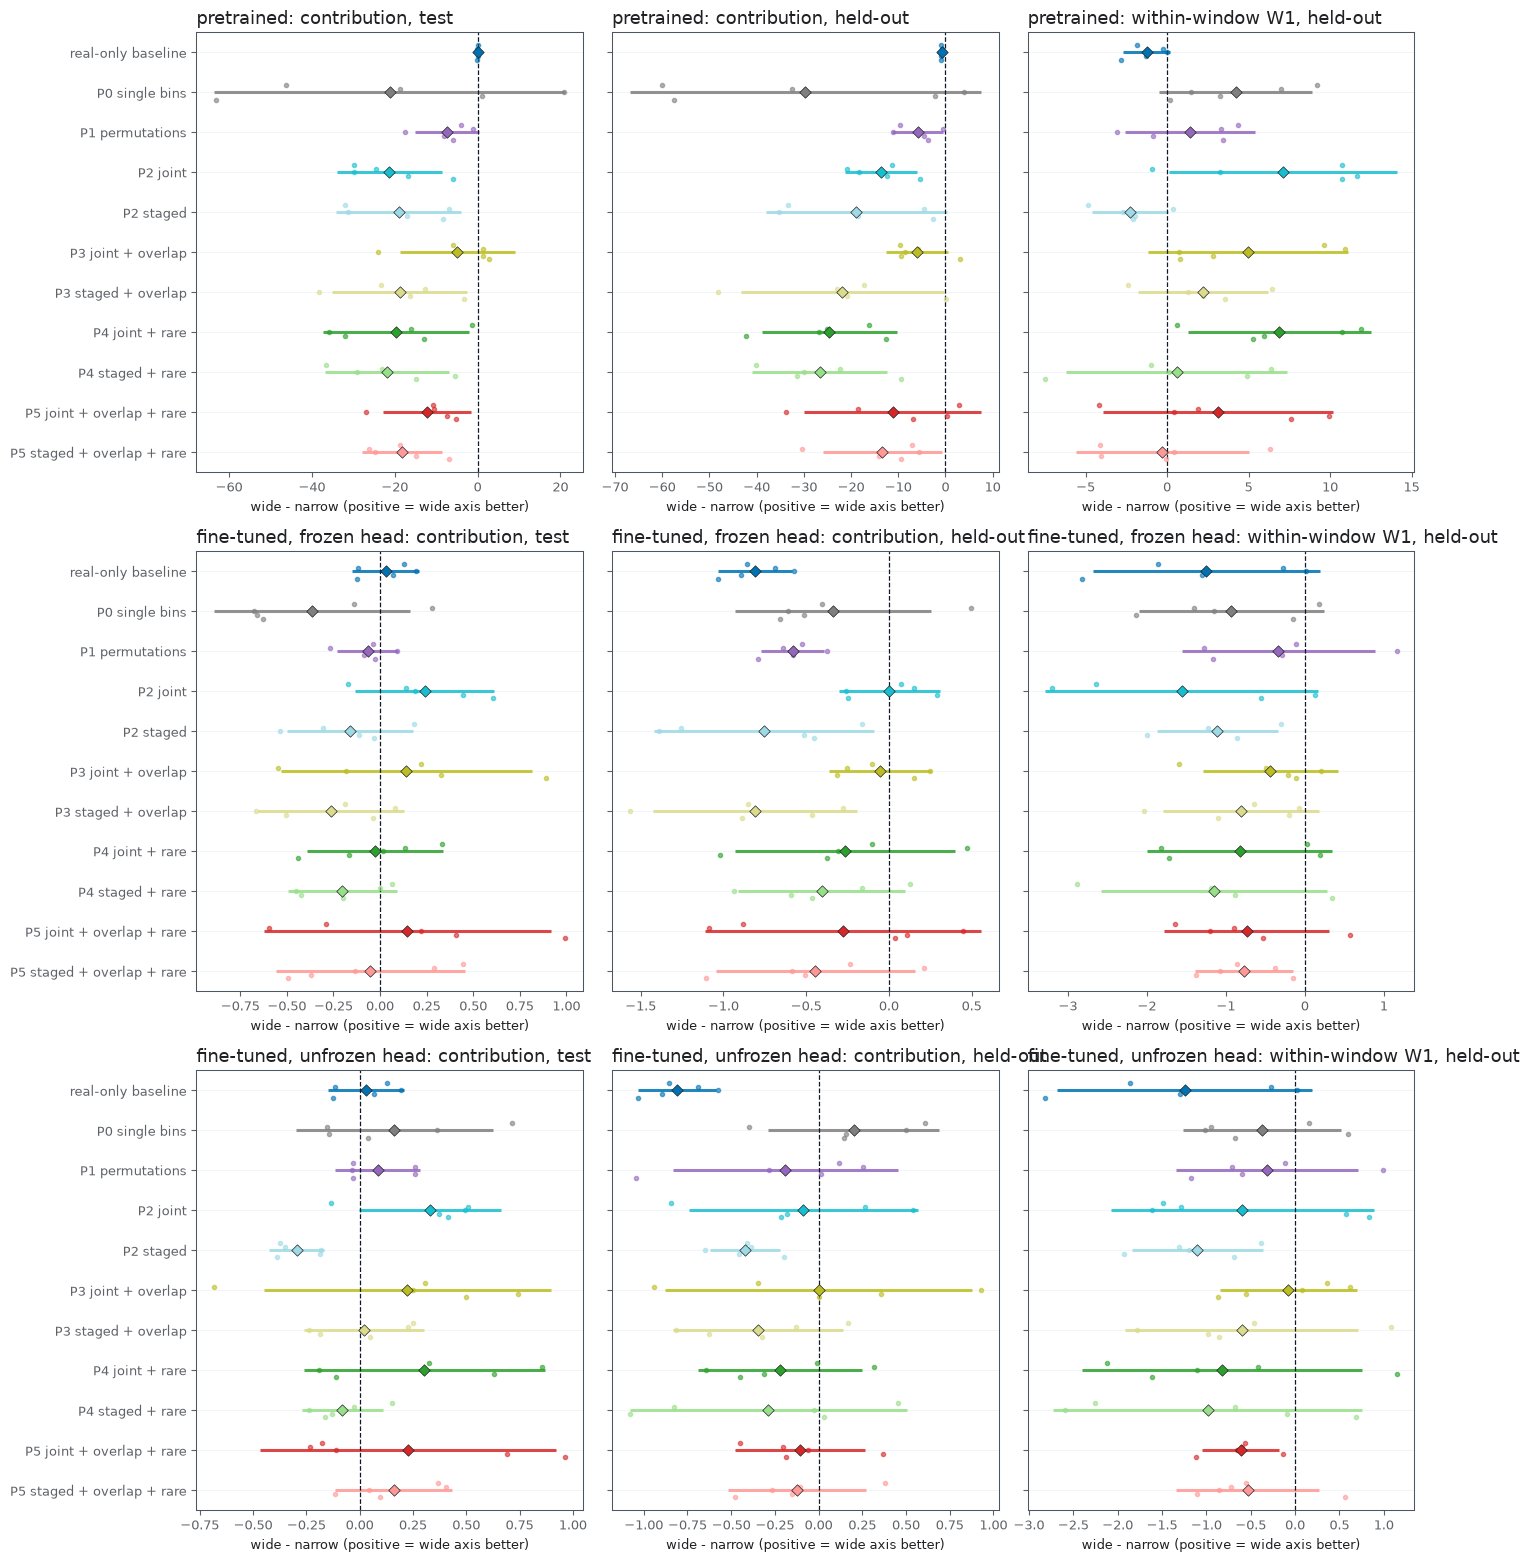

In [6]:
differences = table('axis_difference_summary')
paired = table('axis_differences')
baseline_rows = differences[differences.variant == BASELINE]
expanded = pd.concat([differences[differences.variant != BASELINE], *[baseline_rows.assign(stage=stage) for stage in STAGES]])
baseline_points = paired[paired.variant == BASELINE]
expanded_points = pd.concat([paired[paired.variant != BASELINE], *[baseline_points.assign(stage=stage) for stage in STAGES]])
panels = [(f"{STAGE_LABELS[stage]}: {title}", {**selector, 'stage': stage}) for stage in STAGES for title, selector in PANELS]
figures.improvement_forest(expanded, panels=panels, variants=ORDER, labels=VARIANT_LABELS, colors=VARIANT_COLORS, paired=expanded_points,
                           columns=len(PANELS), xlabel='wide - narrow (positive = wide axis better)', theme=theme);

### Remarks

- Baseline (wide - narrow, sign-adjusted): contribution test 0.0301 [-0.149, 0.21]; within test -0.714 [-1.48, 0.0536]; contribution held-out -0.809 [-1.03, -0.587]; within held-out -1.25 [-2.69, 0.196].
- pretrained: 3 cells favour the wide axis, 14 the narrow axis, of 40.
- frozen head: 0 cells favour the wide axis, 12 the narrow axis, of 40.
- unfrozen head: 0 cells favour the wide axis, 11 the narrow axis, of 40.

### Notes

## Does the wide axis gain more from pretraining?

### Methodology

#### Theoretical

The benefit interaction compares each axis's improvement over its own baseline. It is the relevant quantity
for the question whether pretraining helps more when the axis is wider (more bins for the same latent
dimension).

#### Implementation

`benefit_interaction` (summary over repetitions).

#### Figure descriptions

Forest plot: rows = variants, panels = stage x quantity.

column,frozen_head | contribution | heldout_image,frozen_head | contribution | test,frozen_head | within | heldout_image,frozen_head | within | test,pretrained | contribution | heldout_image,pretrained | contribution | test,pretrained | within | heldout_image,pretrained | within | test,unfrozen_head | contribution | heldout_image,unfrozen_head | contribution | test,unfrozen_head | within | heldout_image,unfrozen_head | within | test
variant,,,,,,,,,,,,
P0_single,"0.47 [-0.0799, 1.02] (+4/-1)","-0.394 [-1.01, 0.224] (+1/-4)","0.315 [-2.02, 2.65] (+2/-3)","-1.01 [-1.99, -0.0373] (+1/-4)","-28.9 [-65.9, 8.21] (+1/-4)","-21.2 [-63.6, 21.1] (+2/-3)","5.46 [0.762, 10.2] (+5/-0)","4.75 [2.71, 6.8] (+5/-0)","1.01 [0.471, 1.55] (+5/-0)","0.133 [-0.236, 0.501] (+3/-2)","0.87 [-1.09, 2.83] (+3/-2)","-0.514 [-0.965, -0.0636] (+0/-5)"
P1_permutation,"0.227 [0.0887, 0.366] (+5/-0)","-0.0962 [-0.232, 0.0397] (+1/-4)","0.909 [-0.472, 2.29] (+4/-1)","0.133 [-0.932, 1.2] (+4/-1)","-5.1 [-10.6, 0.444] (+1/-4)","-7.36 [-15.3, 0.546] (+0/-5)","2.66 [-2.31, 7.63] (+4/-1)","-1.3 [-3.98, 1.37] (+2/-3)","0.62 [0.0558, 1.18] (+4/-1)","0.0547 [-0.257, 0.367] (+3/-2)","0.926 [-0.167, 2.02] (+4/-1)","0.0682 [-0.709, 0.845] (+3/-2)"
P2_joint_base,"0.812 [0.419, 1.21] (+5/-0)","0.211 [-0.275, 0.697] (+3/-2)","-0.311 [-2.97, 2.34] (+2/-3)","-0.546 [-2.2, 1.11] (+2/-3)","-12.8 [-20.6, -5.06] (+0/-5)","-21.4 [-34.1, -8.59] (+0/-5)","8.35 [0.173, 16.5] (+4/-1)","3.29 [-3.64, 10.2] (+4/-1)","0.722 [0.196, 1.25] (+5/-0)","0.3 [-0.13, 0.731] (+4/-1)","0.651 [-2.02, 3.32] (+3/-2)","-0.216 [-1.69, 1.25] (+2/-3)"
P2_staged_base,"0.0543 [-0.807, 0.916] (+3/-2)","-0.192 [-0.601, 0.216] (+2/-3)","0.139 [-1.71, 1.99] (+2/-3)","-0.423 [-1.62, 0.775] (+2/-3)","-18 [-37.3, 1.16] (+0/-5)","-19.1 [-34.3, -3.89] (+0/-5)","-1.02 [-3.24, 1.21] (+2/-3)","-2.02 [-3.37, -0.677] (+0/-5)","0.388 [-0.0177, 0.794] (+4/-1)","-0.326 [-0.464, -0.187] (+0/-5)","0.145 [-1.77, 2.06] (+2/-3)","-0.45 [-1.64, 0.735] (+2/-3)"
P3_joint_overlap,"0.755 [0.405, 1.11] (+5/-0)","0.111 [-0.615, 0.836] (+3/-2)","0.806 [-0.636, 2.25] (+4/-1)","-0.515 [-2.2, 1.17] (+1/-4)","-5.26 [-12, 1.49] (+1/-4)","-4.89 [-19, 9.19] (+3/-2)","6.22 [0.199, 12.3] (+5/-0)","3.51 [-0.356, 7.38] (+4/-1)","0.809 [-0.0552, 1.67] (+4/-1)","0.193 [-0.432, 0.818] (+4/-1)","1.17 [0.0609, 2.28] (+5/-0)","-0.143 [-1.3, 1.02] (+3/-2)"
P3_staged_overlap,"-0.000735 [-0.726, 0.724] (+4/-1)","-0.294 [-0.844, 0.257] (+2/-3)","0.434 [-1.42, 2.29] (+4/-1)","-0.104 [-1.15, 0.942] (+2/-3)","-21 [-42.7, 0.644] (+1/-4)","-18.8 [-35.2, -2.4] (+0/-5)","3.46 [-0.45, 7.37] (+4/-1)","0.547 [-2.04, 3.13] (+3/-2)","0.465 [-0.131, 1.06] (+4/-1)","-0.00961 [-0.409, 0.389] (+3/-2)","0.647 [-1.21, 2.5] (+4/-1)","-0.0137 [-0.815, 0.788] (+2/-3)"
P4_joint_rare,"0.542 [-0.0673, 1.15] (+4/-1)","-0.0562 [-0.382, 0.27] (+2/-3)","0.423 [-1.46, 2.3] (+3/-2)","-0.131 [-1.25, 0.992] (+2/-3)","-23.8 [-38.2, -9.36] (+0/-5)","-19.6 [-37.4, -1.92] (+0/-5)","8.14 [3.52, 12.8] (+5/-0)","4.39 [0.579, 8.19] (+4/-1)","0.589 [0.0802, 1.1] (+4/-1)","0.272 [-0.374, 0.918] (+4/-1)","0.423 [-1.32, 2.17] (+2/-3)","-0.542 [-2.19, 1.1] (+1/-4)"
P4_staged_rare,"0.403 [-0.21, 1.02] (+4/-1)","-0.232 [-0.631, 0.167] (+1/-4)","0.0958 [-2.17, 2.36] (+2/-3)","-0.258 [-1.54, 1.03] (+2/-3)","-25.8 [-40.2, -11.5] (+0/-5)","-21.9 [-36.9, -6.78] (+0/-5)","1.84 [-3.99, 7.66] (+4/-1)","-0.972 [-5.3, 3.35] (+1/-4)","0.521 [-0.321, 1.36] (+3/-2)","-0.111 [-0.371, 0.15] (+2/-3)","0.259 [-2.55, 3.07] (+2/-3)","-0.172 [-1.76, 1.41] (+2/-3)"
P5_joint_all,"0.533 [-0.328, 1.39] (+3/-2)","0.117 [-0.693, 0.927] (+3/-2)","0.508 [-1.39, 2.41] (+3/-2)","-0.896 [-3.15, 1.36] (+1/-4)","-10.4 [-29.3, 8.53] (+2/-3)","-12.2 [-22.9, -1.45] (+0/-5)","4.38 [-3.2, 12] (+4/-1)","1.75 [-1.57, 5.07] (+3/-2)","0.705 [0.265, 1.14] (+5/-0)","0.198 [-0.582, 0.978] (+2/-3)","0.632 [-0.683, 1.95] (+3/-2)","-0.52 [-2.39, 1.35] (+1/-4)"


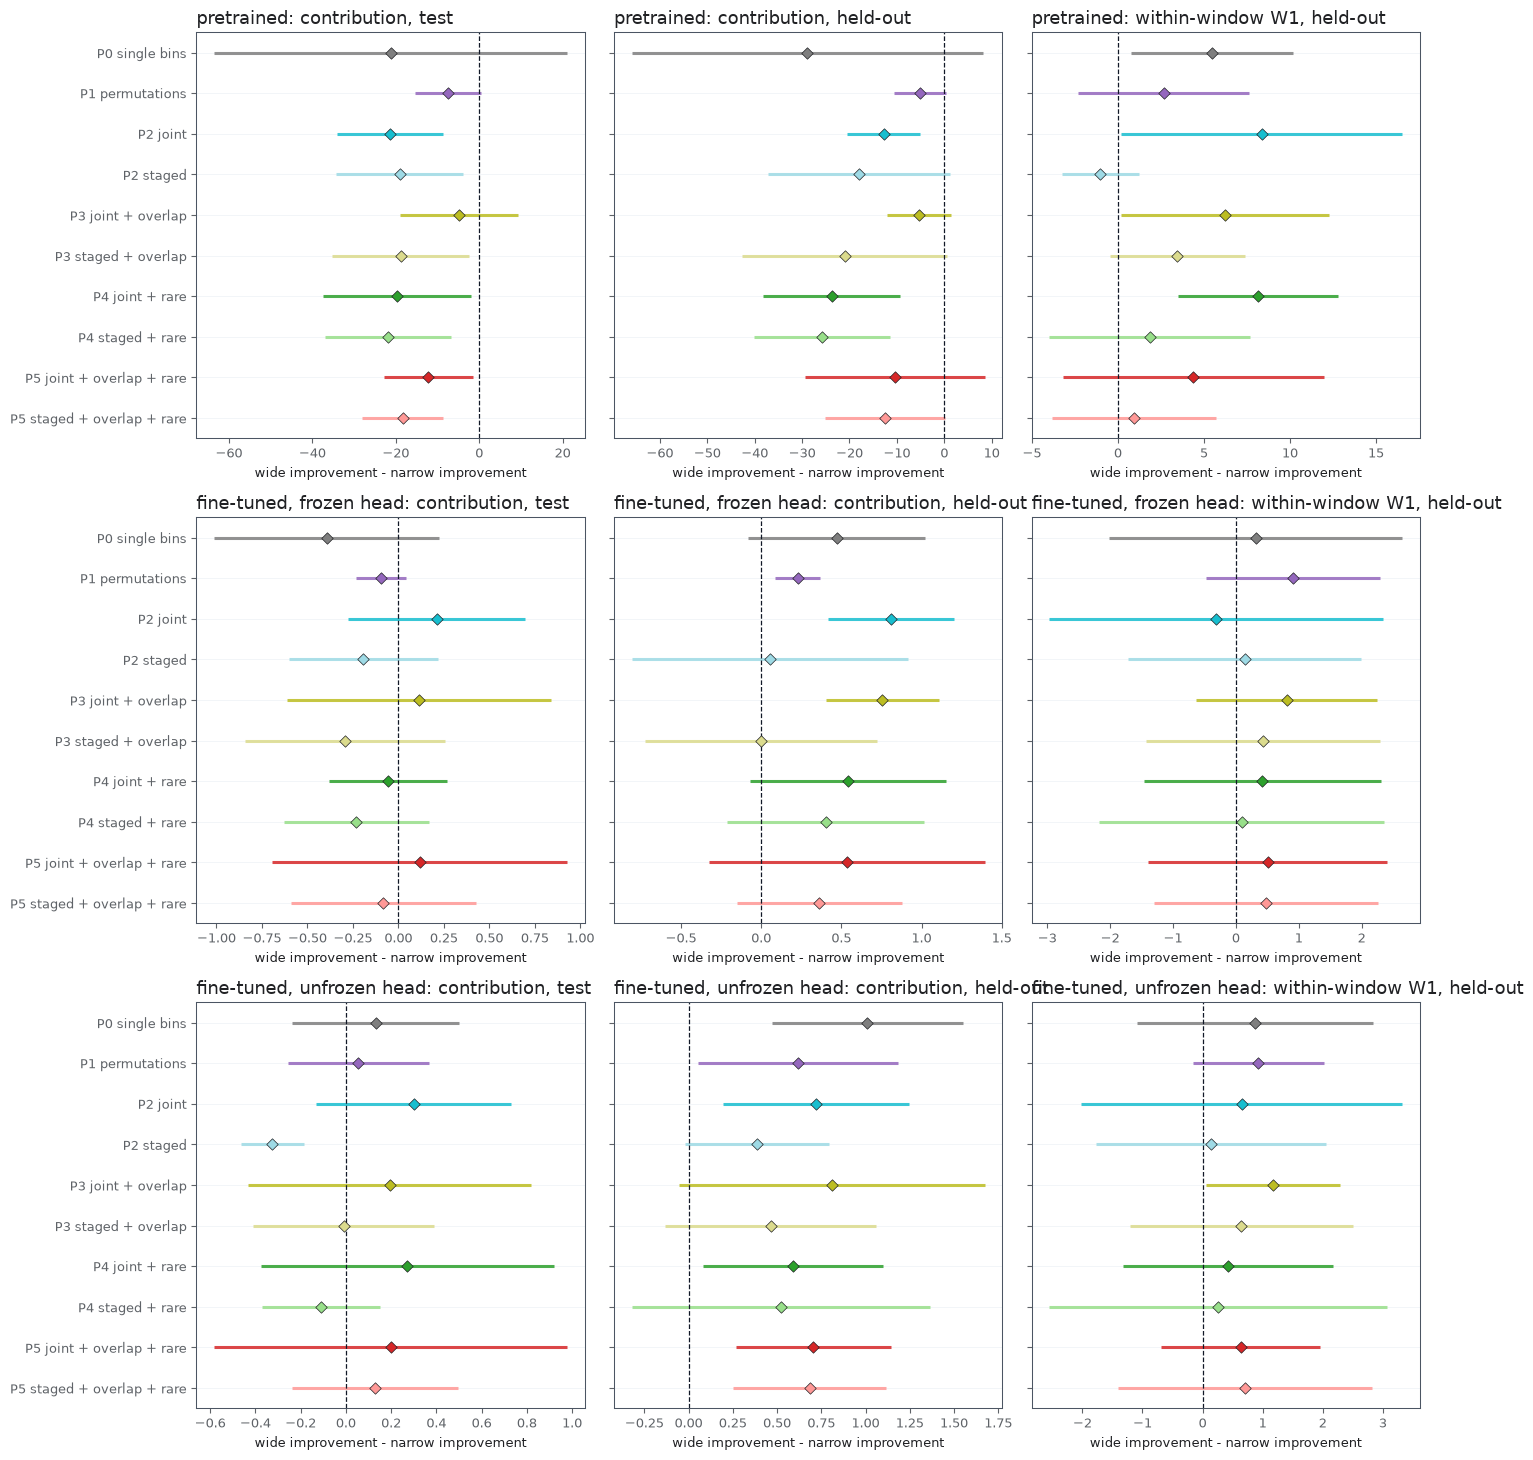

In [7]:
interaction = table('benefit_interaction')
figures.improvement_forest(interaction, panels=panels, variants=VARIANTS, labels=VARIANT_LABELS, colors=VARIANT_COLORS, columns=len(PANELS),
                           xlabel='wide improvement - narrow improvement', theme=theme);
display(interaction.assign(result=interval(interaction), column=interaction.stage + ' | ' + interaction.metric + ' | ' + interaction.evaluation)
        .pivot_table(index='variant', columns='column', values='result', aggfunc='first').reindex(VARIANTS))

### Remarks

- frozen head, contribution, held-out: wide axis gains more for 3, less for 0 of 10 variants.
- frozen head, contribution, test: wide axis gains more for 0, less for 0 of 10 variants.
- frozen head, within, held-out: wide axis gains more for 0, less for 0 of 10 variants.
- frozen head, within, test: wide axis gains more for 0, less for 1 of 10 variants.
- pretrained, contribution, held-out: wide axis gains more for 0, less for 3 of 10 variants.
- pretrained, contribution, test: wide axis gains more for 0, less for 7 of 10 variants.
- pretrained, within, held-out: wide axis gains more for 4, less for 0 of 10 variants.
- pretrained, within, test: wide axis gains more for 2, less for 1 of 10 variants.
- unfrozen head, contribution, held-out: wide axis gains more for 6, less for 0 of 10 variants.
- unfrozen head, contribution, test: wide axis gains more for 0, less for 1 of 10 variants.
- unfrozen head, within, held-out: wide axis gains more for 1, less for 0 of 10 variants.
- unfrozen head, within, test: wide axis gains more for 0, less for 1 of 10 variants.

### Notes

## Results / Summary

### LLM

- **Observed:** on the shared windows the baseline itself is not better on the wide axis (held-out contribution favours the narrow axis, -0.81); after fine-tuning 11-12 of 40 cells favour the narrow axis and none the wide axis, as for the baseline; but at the unfrozen stage 6 of 10 variants gain more from pretraining on the wide axis in the held-out contribution (they close part of the wide axis's gap).
- **Interpretation:** the benefit of pretraining for the reconstruction of new images, where it exists, is specific to the wide axis (consistent with 3_01 and 3_07 on 100-3000).

**Absolute levels against the real-only baseline** (means over repetitions; 'better' compares means only, without a test; the intervals are in the improvement sections):

- axis-200-900: window contribution to W1, test (by stage): baseline 3.117; others 3.36-64.55; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (3.36), worst pretrained (64.55).
- axis-200-900: window contribution to W1, test (unfrozen head, per variant): baseline 3.117; others 3.025-3.49; 1 of 10 better than the baseline; best P1 permutations (3.025), worst P4 joint + rare (3.49).
- axis-200-900: within-window W1, test (by stage): baseline 4.747; others 5.134-20.81; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (5.134), worst pretrained (20.81).
- axis-200-900: within-window W1, test (unfrozen head, per variant): baseline 4.747; others 4.652-5.584; 1 of 10 better than the baseline; best P1 permutations (4.652), worst P4 joint + rare (5.584).
- axis-200-900: window contribution to W1, heldout_image (by stage): baseline 3.076; others 3.401-49.63; 0 of 3 better than the baseline; best fine-tuned, frozen head (3.401), worst pretrained (49.63).
- axis-200-900: window contribution to W1, heldout_image (unfrozen head, per variant): baseline 3.076; others 3.123-3.678; 0 of 10 better than the baseline; best P1 permutations (3.123), worst P0 single bins (3.678).
- axis-200-900: within-window W1, heldout_image (by stage): baseline 5.222; others 5.406-22.68; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (5.406), worst pretrained (22.68).
- axis-200-900: within-window W1, heldout_image (unfrozen head, per variant): baseline 5.222; others 5.011-5.791; 3 of 10 better than the baseline; best P2 staged (5.011), worst P0 single bins (5.791).
- axis-100-3000: window contribution to W1, test (by stage): baseline 3.087; others 3.247-81; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (3.247), worst pretrained (81).
- axis-100-3000: window contribution to W1, test (unfrozen head, per variant): baseline 3.087; others 2.94-3.517; 1 of 10 better than the baseline; best P1 permutations (2.94), worst P4 staged + rare (3.517).
- axis-100-3000: within-window W1, test (by stage): baseline 5.46; others 6.105-20.28; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (6.105), worst pretrained (20.28).
- axis-100-3000: within-window W1, test (unfrozen head, per variant): baseline 5.46; others 5.298-6.84; 1 of 10 better than the baseline; best P1 permutations (5.298), worst P4 joint + rare (6.84).
- axis-100-3000: window contribution to W1, heldout_image (by stage): baseline 3.885; others 3.566-66.8; 2 of 3 better than the baseline; best fine-tuned, unfrozen head (3.566), worst pretrained (66.8).
- axis-100-3000: window contribution to W1, heldout_image (unfrozen head, per variant): baseline 3.885; others 3.307-3.885; 9 of 10 better than the baseline; best P5 joint + overlap + rare (3.307), worst P4 staged + rare (3.885).
- axis-100-3000: within-window W1, heldout_image (by stage): baseline 6.468; others 6.009-19.88; 2 of 3 better than the baseline; best fine-tuned, unfrozen head (6.009), worst pretrained (19.88).
- axis-100-3000: within-window W1, heldout_image (unfrozen head, per variant): baseline 6.468; others 5.651-6.564; 9 of 10 better than the baseline; best P1 permutations (5.651), worst P4 staged + rare (6.564).

### Person